# Historical weather data for Vienna City Marathon dates

To access the weather on the days the marathon took place the following REST API was used: https://api.openweathermap.org

## Cleaning/Accessing the data

Import relevant libraries

In [2]:
!pip install python-dotenv

^C


In [3]:
from dotenv import load_dotenv
import os
import requests, time
import pandas as pd
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


get key for the weather API from .env

In [ ]:
load_dotenv()
weather_key = os.getenv("weather_key")


save coordinates for Vienna so that it can be used in the API call

In [ ]:
LAT, LON = 48.2082, 16.3738

save relevant marathon dates (from 2000 onwards, 2020 was canceled)

In [ ]:
marathon_dates = {
    2017: "2017-04-23",
    2018: "2018-04-22", 2019: "2019-04-07",
    # 2020 cancelled
    2021: "2021-09-12", 2022: "2022-04-24", 2023: "2023-04-23",
    2024: "2024-04-21", 2025: "2025-04-06", 2026: "2026-04-19",
}

fetch historical weather on marathon dates

In [ ]:
def get_weather(date_str):
    dt = datetime.strptime(date_str, "%Y-%m-%d").replace(hour=9, tzinfo=timezone.utc)
    ts = int(dt.timestamp())

    r = requests.get(
        "https://api.openweathermap.org/data/3.0/onecall/timemachine",  # hardcoded
        params={
            "lat": LAT, "lon": LON,
            "dt": ts,
            "appid": weather_key,
            "units": "metric"
        }
    )
    if r.status_code != 200:
        print(f"  ✗ Error {r.status_code}: {r.json()}")
        return {}

    d = r.json().get("data", [{}])[0]
    return {
        "temp_c":     d.get("temp"),
        "feels_like": d.get("feels_like"),
        "humidity":   d.get("humidity"),
        "wind_kph":   round(d.get("wind_speed", 0) * 3.6, 1),
        "weather":    d.get("weather", [{}])[0].get("description"),
        "clouds":     d.get("clouds"),
        "rain_mm":    d.get("rain", {}).get("1h", 0),
    }

Fetch all relevant dates

In [ ]:
results = {}
for year, date in marathon_dates.items():
    print(f"Fetching {year}...", end=" ")
    results[year] = get_weather(date)
    print("✓")
    time.sleep(0.5)


build dataframe and save results in csv

In [ ]:
rows = [{"year": year, "date": date, **results.get(year, {})}
        for year, date in marathon_dates.items()]

df = pd.DataFrame(rows).set_index("year")
print(df)
df.to_csv("weather.csv")

## Visualisation

In [9]:
df = pd.read_csv("weather.csv")
df["date"] = pd.to_datetime(df["date"])
df["rained"] = df["rain_mm"] > 0
print(df.head())

   year       date  temp_c  feels_like  humidity  wind_kph        weather  \
0  2000 2000-05-21   14.97       13.70        45       7.6     few clouds   
1  2001 2001-05-20   16.18       15.13        49       7.2  broken clouds   
2  2002 2002-05-26   12.43       12.05        89      21.6     light rain   
3  2003 2003-05-25   24.67       24.76        60      25.2      clear sky   
4  2004 2004-05-16   13.02       12.00        62      21.6     few clouds   

   clouds  rain_mm                  era  rained  
0      20     0.00  May era (2000–2006)   False  
1      75     0.00  May era (2000–2006)   False  
2      40     0.26  May era (2000–2006)    True  
3       9     0.00  May era (2000–2006)   False  
4      20     0.00  May era (2000–2006)   False  


The following plot shows the temperature in Vienna on Marathon day. Note that since the marathon used to be in may and now is in april (or was in september in 2021) the temperatures can't necessarily be compared.

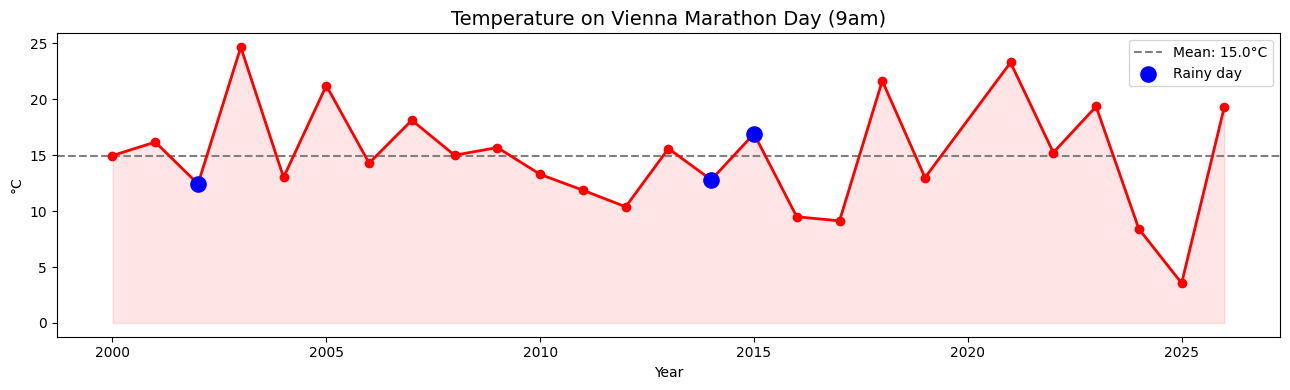

In [10]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["year"], df["temp_c"], marker="o", color="red", linewidth=2, zorder=3)
ax.fill_between(df["year"], df["temp_c"], alpha=0.1, color="red")
ax.axhline(df["temp_c"].mean(), linestyle="--", color="gray",
           label=f"Mean: {df['temp_c'].mean():.1f}°C")
rainy = df[df["rained"]]
ax.scatter(rainy["year"], rainy["temp_c"], s=120, color="blue",
           zorder=5, label="Rainy day")
ax.set_title("Temperature on Vienna Marathon Day (9am)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("°C")
ax.legend()
plt.tight_layout()
plt.savefig("weather_temp.png", dpi=150)
plt.show()

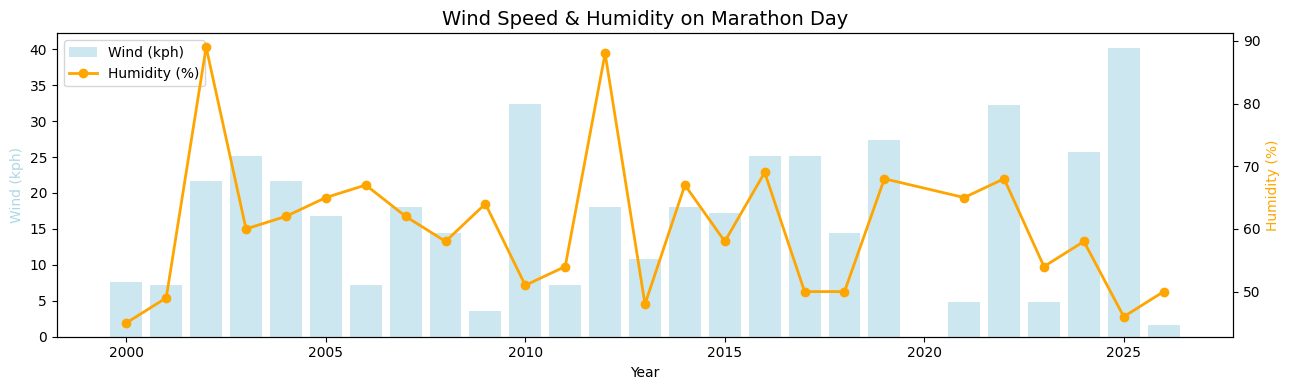

In [12]:
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.bar(df["year"], df["wind_kph"], color="lightblue", alpha=0.6, label="Wind (kph)")
ax2.plot(df["year"], df["humidity"], color="orange", marker="o", linewidth=2, label="Humidity (%)")
ax1.set_ylabel("Wind (kph)", color="lightblue")
ax2.set_ylabel("Humidity (%)", color="orange")
ax1.set_xlabel("Year")
ax1.set_title("Wind Speed & Humidity on Marathon Day", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig("weather_wind_humidity.png", dpi=150)
plt.show()

The following plot shows the running comfort by year. This comfort level was caculated using the Wet-bulb globe temperature(Wbg), which measures heat as it affects humans and animals. However, since we don't have heat radiation wasn't available in our data we omit this component. (Stull (2011) Wet bulb Formel: "Wet-Bulb Temperature from Relative Humidity and Air Temperature", Journal of Applied Meteorology and Climatology
ACSM (American College of Sports Medicine). Risikokategorien für Laufveranstaltungen: die <18°C / 18–23°C / 23–28°C / >28°C Schwellenwerte kommen von deren offiziellen Guidelines für Ausdauersport)

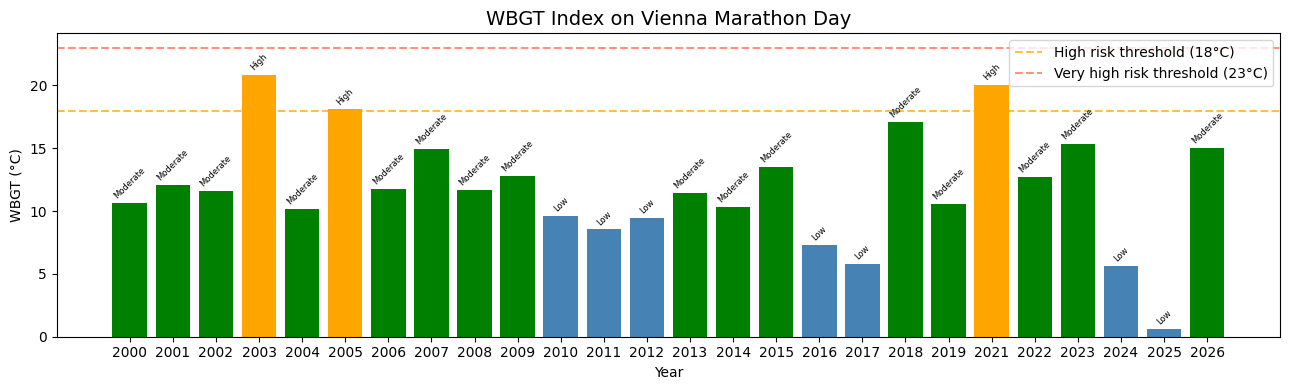

In [14]:
def wet_bulb(T, rh):
    return (T * np.arctan(0.151977 * (rh + 8.313659)**0.5)
            + np.arctan(T + rh)
            - np.arctan(rh - 1.676331)
            + 0.00391838 * rh**1.5 * np.arctan(0.023101 * rh)
            - 4.686035)

df["wet_bulb"] = wet_bulb(df["temp_c"], df["humidity"])
df["wbgt"] = 0.7 * df["wet_bulb"] + 0.3 * df["temp_c"]

# ACSM risk categories for running events
def wbgt_risk(w):
    if w < 10:   return "Low"
    elif w < 18: return "Moderate"
    elif w < 23: return "High"
    elif w < 28: return "Very High"
    else:        return "Extreme"

df["risk"] = df["wbgt"].apply(wbgt_risk)

color_map = {
    "Low": "steelblue", "Moderate": "green",
    "High": "orange", "Very High": "red", "Extreme": "darkred"
}
colors = df["risk"].map(color_map)

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(df["year"].astype(str), df["wbgt"], color=colors)
ax.axhline(18, linestyle="--", color="orange", alpha=0.7, label="High risk threshold (18°C)")
ax.axhline(23, linestyle="--", color="tomato", alpha=0.7, label="Very high risk threshold (23°C)")
ax.set_title("WBGT Index on Vienna Marathon Day", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("WBGT (°C)")
ax.legend()

# add risk labels on bars
for bar, risk in zip(bars, df["risk"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            risk, ha="center", va="bottom", fontsize=6, rotation=45)

plt.tight_layout()
plt.savefig("weather_wbgt.png", dpi=150)
plt.show()